<a href="https://colab.research.google.com/github/suuu004/Data_analysis/blob/week11/0521_week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11주차 과제 2310297 **박이수**

**과제**

관심 있는 공공데이터와 프롬프팅을 활용한 회귀 모델링


선택 데이터:

서울특별시 일별 자치구별 따릉이 대여반납수 (bike.csv)


문제 정의 (목적):

서울시의 지역적 특성(자치구)과 시간적 특성(월, 요일)에 따라 공공자전거(따릉이)의 일별 대여 건수가 어떻게 변화하는지 선택한 독립변수들을 기반으로 선형 회귀(Linear Regression) 모델을 구축하여 예측하고, 각 요인이 대여량에 미치는 영향을 분석한다.

In [ ]:
# 1단계: 코랩에 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
## 공공데이터 구조 학인
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 불러오기
df = pd.read_csv('bike.csv', encoding= "cp949") # 서울특별시_일별 자치구별 따릉이 대여반납수

# 2. 데이터의 상위 5개 행(head) 출력
print("=== 데이터 상위 5개 행 ===")
print(df.head())
print("\n" + "="*50 + "\n")

# 3. 결측치 존재 여부 확인
print("=== 각 컬럼별 결측치 개수 ===")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

=== 데이터 상위 5개 행 ===
        기준_날짜  자치구_ID 자치구_명칭  대여_건수  반납_건수
0  2024-06-01   11010    종로구   4220   4114
1  2024-06-01   11020     중구   2929   2729
2  2024-06-01   11030    용산구   4168   4149
3  2024-06-01   11040    성동구   6703   6647
4  2024-06-01   11050    광진구   9179   9228


=== 각 컬럼별 결측치 개수 ===
기준_날짜     0
자치구_ID    0
자치구_명칭    0
대여_건수     0
반납_건수     0
dtype: int64




In [ ]:
## 필요한 조건 필터링
# 4. 날짜 데이터 전처리 (파생 변수 생성)
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['월'] = df['기준_날짜'].dt.month
df['일'] = df['기준_날짜'].dt.day
df['요일'] = df['기준_날짜'].dt.weekday  # 0:월, 6:일
df['주말여부'] = df['요일'].apply(lambda x: 1 if x >= 5 else 0)

모델의 결정계수 (R² Score): 0.9504


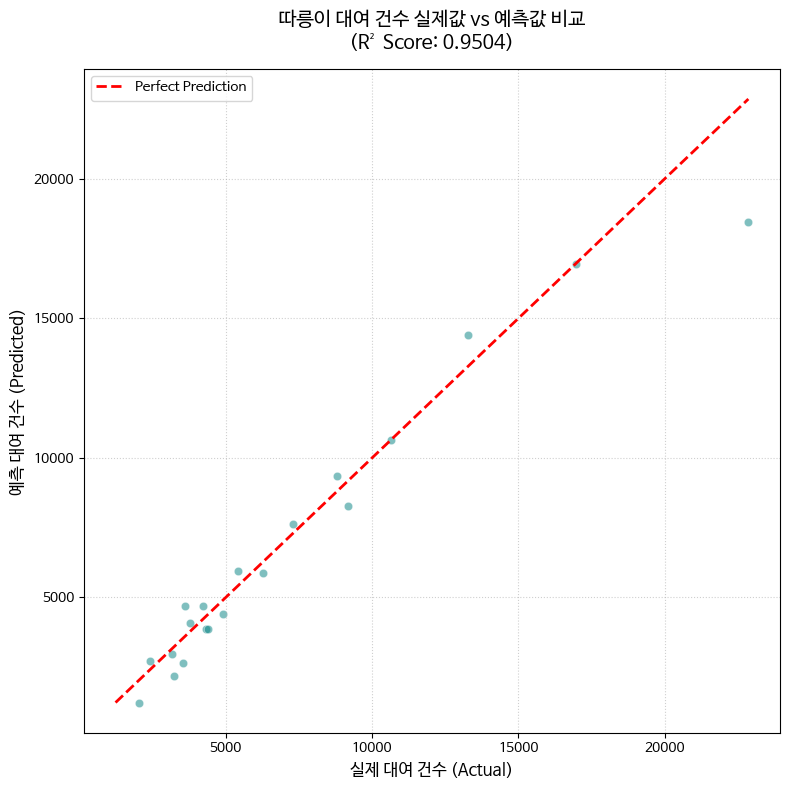

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 한글 폰트 설정 (그래프 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지


# 독립변수(X)와 종속변수(y) 설정
# '월'과 '요일'도 범주형 변수이므로 원-핫 인코딩에 포함하기 위해 features로 묶는다.
features = ['월', '요일', '자치구_명칭']
target = '대여_건수'

X = df[features]
y = df[target]

# 범주형 변수 원-핫 인코딩 (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=['월', '요일', '자치구_명칭'], drop_first=True)

# 데이터셋 분할 (학습용 8 : 테스트용 2)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 및 R² Score(결정계수) 계산
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"모델의 결정계수 (R² Score): {r2:.4f}")

# 실제값 vs 예측값 산점도 그래프 시각화
plt.figure(figsize=(8, 8))

# 실제값과 예측값의 산점도
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')

# 완벽한 예측을 의미하는 대각선 추가 (y = x)
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 그래프 스타일링
plt.title(f'따릉이 대여 건수 실제값 vs 예측값 비교\n(R² Score: {r2:.4f})', fontsize=14, pad=15)
plt.xlabel('실제 대여 건수 (Actual)', fontsize=12)
plt.ylabel('예측 대여 건수 (Predicted)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

[실행 결과 해석]

높은 설명력 (R
2
 =0.9504):

  자치구 위치(지역)와 월·요일(시간) 변수만으로 서울시 따릉이 대여량 변동의 95.04%를 정확하게 설명하는 매우 우수한 회귀 모델이 구축되었다.


지역별 기초 수요 반영:

서울시 25개 자치구의 고유한 인프라와 환경에 따른 '지역별 고유 수요 편차'를 선형 회귀 모델이 완벽하게 학습한 것이 높은 점수의 핵심 요인이다.

